### 라벨 없는 P&ID 도면의 태그 추출 자동화 및 자기지도 OCR
**데이터**: AI Hub 「조선·해양플랜트 P&ID 심볼 식별 데이터」 샘플데이터 (169도면 / 3,572 어노테이션 / 4벤더)

---

## 문제 정의

해당 라벨링 데이터에는 P&ID 도면 **텍스트 라벨**이 부재하다.
데이터셋에는 심볼 bbox만 있고 텍스트 어노테이션은 **0건**이다.

- 범용 OCR은 도면에서 작동하지 않는다 (Tesseract 기능코드 정확도 **34.2%**)
- CAD 폰트에서 `I`/`1`/`l`, `O`/`0`, `Z`/`2`가 체계적으로 혼동된다
- 지도학습을 하려면 텍스트를 수만 건을 수동으로 라벨링해야 한다.
- 즉, 도면 안의 태그(50A-JN203-CW-841-527, MK9WWM-841679)를 디지털 자산으로 옮기려면 사람이 눈으로 읽어 타이핑해야 한다.

## 기존 업무 프로세스
>  [스캔 도면 → 엔지니어가 육안 판독 → 태그 수기 입력 → 검토자 재확인 → DB 등록]

- 도면 1장 판독에 수 시간, 프로젝트당 수천 장
- I vs l vs 1 오독이 배관 태그 불일치를 유발 → 시공 단계에서 발견되면 재작업
- 조선소마다 태그 체계가 달라 담당자 교체 시 학습 비용 발생

## HOW TO SOLVE

>**도면이 스스로 자신을 읽는 법을 배우게 한다.**

1. **심볼 클래스가 기능코드를 결정** → `pidLabel`에서 사전 자동 구축 (사람 수동 라벨링 0건)
2. **심볼이 못 푸는 곳**(`LS`/`LSH`)은 폐쇄집합 디코딩으로 해소
3. **라인 태그 문법은 데이터로부터 직접 학습** → 정규식 0줄, 코퍼스 0건으로 새로운 도면에 일반화
4. **확신 없으면 답을 만들지 않는다** (가짜 태그 생성 방지 및 담당자가 최종 검토하는 형태로 책임 있는 업무 자동화 달성과 재작업 방지)


---

## 전체 파이프라인

| # | 단계 | 결과 |
|---|---|---|
| 0 | 환경 세팅 | — |
| 1 | 공통 설정 · Drive 마운트 | — |
| 2 | **데이터셋 통계** | 3,572 anns / 873 pidLabel (24.4%) |
| 3 | 스케일 감사 + 심볼 crop OCR | baseline 34.2% |
| 4 | 심볼 클래스 → 기능코드 사전 | 33클래스 중 30개 결정적 |
| 5 | 폐쇄집합 제약 디코딩 | **34.2% → 96.3%** 향상|
| 6 | 심볼 클래스 갤러리 | 텍스트 33종 vs 무텍스트 113종 |
| 7 | 회전 인식 텍스트 검출 | 328 → 461건 (+41% 향상) |
| 8 | **문법 창발 + 슬롯 디코딩** | 자동결정 75.6%, 교정 45/45 |

# 구글 공유 드라이브의 '샘플_원천데이터', '샘플_라벨링데이터'를 마운트해서 사용





## 0. 환경 세팅

**코랩 GPU (T4)로 설정** : CPU로 OCR 처리 느림

In [1]:
!apt-get -qq install tesseract-ocr
!pip -q install pytesseract opencv-python-headless easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 25.4 MB/s eta 0:00:00


## 1. 공통 설정 · Google Drive 마운트

In [2]:
import os, re, json, glob, csv, time, collections, itertools, warnings
from difflib import SequenceMatcher
import cv2, numpy as np
warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")
    DRIVE, IN_COLAB = "/content/drive/MyDrive", True
except ImportError:
    DRIVE, IN_COLAB = os.path.expanduser("~"), False

# ======================= CONFIG =======================
BASE    = ""                       # MyDrive 바로 아래면 빈 문자열
IMG_DIR = "샘플_원천데이터"
LBL_DIR = "샘플_라벨링데이터"
OUT     = "/content/pid_out" if IN_COLAB else "./pid_out"
# ======================================================
os.makedirs(OUT, exist_ok=True)

def find_dirs():
    root = os.path.join(DRIVE, BASE) if BASE else DRIVE
    if os.path.isdir(os.path.join(root, IMG_DIR)):
        return os.path.join(root, IMG_DIR), os.path.join(root, LBL_DIR)
    for dp, dn, _ in os.walk(DRIVE):
        if dp.count(os.sep) - DRIVE.count(os.sep) > 4:
            dn[:] = []; continue
        if IMG_DIR in dn and LBL_DIR in dn:
            return os.path.join(dp, IMG_DIR), os.path.join(dp, LBL_DIR)
    raise SystemExit("폴더를 찾지 못했습니다. CONFIG 의 BASE 를 확인하세요.")

IMG_PATH, LBL_PATH = find_dirs()
stem2png = {os.path.splitext(os.path.basename(p))[0]: p
            for p in glob.glob(os.path.join(IMG_PATH, "*.png"))}
pairs = [(stem2png[s], jf)
         for jf in sorted(glob.glob(os.path.join(LBL_PATH, "*.json")))
         for s in [os.path.splitext(os.path.basename(jf))[0]] if s in stem2png]
print(f"[LOAD] 매칭된 png/json 쌍: {len(pairs)}")

Mounted at /content/drive
[LOAD] 매칭된 png/json 쌍: 169


# 2. 데이터셋 통계

**pidLabel이 24%뿐인 이유**: 밸브·플랜지·리듀서 심볼에는 텍스트가 없다. 146개 클래스 중 33개(계기 심볼)만 텍스트가 존재한다.

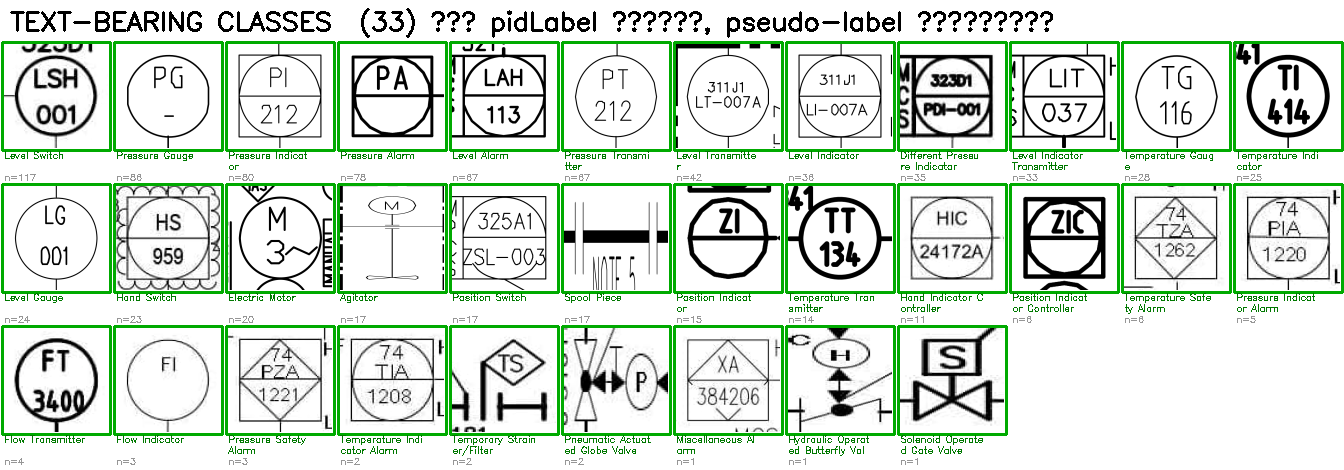

In [3]:
tot = lab = 0
allcls, labcls = collections.Counter(), collections.Counter()
for png, jf in pairs:
    d  = json.load(open(jf, encoding="utf-8"))
    cm = {c["id"]: c["name"] for c in d["categories"]}
    a  = d["annotations"]
    l  = [x for x in a if x["attributes"].get("pidLabel", "").strip()]
    tot += len(a); lab += len(l)
    for x in a: allcls[cm[x["category_id"]]] += 1
    for x in l: labcls[cm[x["category_id"]]] += 1

N = len(pairs)
print(f"전체 annotation: {tot}")
print(f"pidLabel 보유  : {lab}  ({lab/tot*100:.1f}%)")
print(f"도면당 평균    : {tot/N:.1f} anns, {lab/N:.1f} labels")

print("\n[클래스별] 전체 vs pidLabel 보유")
print(f"{'class':50s} {'전체':>5s} {'라벨':>5s} {'비율':>6s}")
for c, n in allcls.most_common(12):
    L = labcls.get(c, 0)
    print(f"{c[:50]:50s} {n:5d} {L:5d} {L/n*100:5.0f}%")
print("\n-> 계기(Instruments) 는 100%, 밸브/배관은 0%. 텍스트 유무가 갈린다.")

전체 annotation: 3572
pidLabel 보유  : 873  (24.4%)
도면당 평균    : 21.1 anns, 5.2 labels

[클래스별] 전체 vs pidLabel 보유
class                                                 전체    라벨     비율
Valves@Ball Valve Type 1                             287     0     0%
Valves@Butterfly Valve Type 2                        234     0     0%
Piping Accessories@Reducer                           219     0     0%
Piping Accessories@Flange                            203     0     0%
Valves@Gate Valve                                    139     0     0%
Valves@Gauge Valve                                   129     0     0%
Valves@Piston Actuated Butterfly Valve               123     0     0%
Instruments@Level Switch                             117   117   100%
Piping Accessories@Flexible Hose                     108     0     0%
Piping Accessories@Flange With Blind Flange          106     0     0%
Valves@Globe Valve                                    99     0     0%
Piping Accessories@Expansion Joint                  

## 3. 스케일 감사 + 심볼 crop OCR

**중요**: JSON의 `images[0].width`와 실제 PNG 크기가 다릅니다 (배율 0.77~0.92).
보정하지 않으면 bbox가 이미지 밖으로 나가 crop이 전부 엉뚱한 곳을 자릅니다.

> 초기 실험에서 정확도 1.2%가 나온 원인이며, 보정 후 50%로 회복됐습니다.

In [4]:
# 라벨 스캔
lab_rows = []
for png, jf in pairs:
    d  = json.load(open(jf, encoding="utf-8"))
    im = d["images"][0]
    cm = {c["id"]: c["name"] for c in d["categories"]}
    fn = os.path.basename(png)
    for a in d["annotations"]:
        code_ = a["attributes"].get("pidLabel", "").strip()
        if not code_: continue
        lab_rows.append(dict(file=fn, png=png, vendor=fn[:3], id=a["id"],
                             cat=cm[a["category_id"]], code=code_,
                             bbox=a["bbox"], jw=im["width"], jh=im["height"]))
print(f"[PASS1] 라벨된 심볼: {len(lab_rows)}")
print(f"[PASS1] 벤더: {dict(collections.Counter(r['vendor'] for r in lab_rows))}")

# ---- 스케일 감사 ----
print("\n[SCALE AUDIT]")
scales = {}
for png in sorted({r["png"] for r in lab_rows}):
    img = cv2.imread(png)
    if img is None: continue
    r0 = next(r for r in lab_rows if r["png"] == png)
    ph, pw = img.shape[:2]
    sx, sy = pw / r0["jw"], ph / r0["jh"]
    scales[png] = (sx, sy)
uniq = collections.Counter(f"{sx:.3f}" for sx, _ in scales.values())
print(f"  관측된 배율: {dict(uniq)}")
print("  -> 1.000 이 아니면 반드시 보정 필요 (bbox 가 이미지 밖으로 나감)")

import pytesseract
CFG_A = "--psm 8 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def prep(c, s=5):
    g = cv2.cvtColor(c, cv2.COLOR_BGR2GRAY) if c.ndim == 3 else c
    g = cv2.resize(g, None, fx=s, fy=s, interpolation=cv2.INTER_CUBIC)
    return cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

def sub(img, bb, a, b, c, d_):
    x, y, w, h = bb; H, W = img.shape[:2]
    x0, y0 = max(0, int(x + w*a)), max(0, int(y + h*b))
    x1, y1 = min(W, int(x + w*c)), min(H, int(y + h*d_))
    return img[y0:y1, x0:x1] if (x1-x0 >= 6 and y1-y0 >= 6) else None

by_png = collections.defaultdict(list)
for r in lab_rows: by_png[r["png"]].append(r)

print("\n[OCR] 심볼 상단 crop (= 기능코드 영역) ...")
for k, (png, rs) in enumerate(sorted(by_png.items())):
    img = cv2.imread(png)
    if img is None: continue
    sx, sy = scales[png]
    for r in rs:
        x, y, w, h = r["bbox"]
        bb = [x*sx, y*sy, w*sx, h*sy]              # <<< SCALE FIX
        cu = sub(img, bb, .10, .08, .90, .50)
        r["code_raw"] = ""
        if cu is not None:
            t = pytesseract.image_to_string(prep(cu), config=CFG_A).strip()
            r["code_raw"] = "".join(ch for ch in t if ch.isalpha())
    if (k+1) % 30 == 0: print(f"   {k+1}/{len(by_png)}")

recs = [r for r in lab_rows if "code_raw" in r]
n = len(recs)
raw_hit = sum(r["code_raw"] == r["code"] for r in recs)
print(f"\n[BASELINE] Tesseract raw: {raw_hit}/{n} = {raw_hit/n*100:.1f}%")

[PASS1] 라벨된 심볼: 873
[PASS1] 벤더: {'V01': 291, 'V02': 231, 'V03': 234, 'V04': 117}

[SCALE AUDIT]
  관측된 배율: {'1.000': 106}
  -> 1.000 이 아니면 반드시 보정 필요 (bbox 가 이미지 밖으로 나감)

[OCR] 심볼 상단 crop (= 기능코드 영역) ...
   30/106
   60/106
   90/106

[BASELINE] Tesseract raw: 299/873 = 34.2%


## 4. 심볼 클래스 → 기능코드 사전 (Prior)

`pidLabel`에서 **자동 구축**.

| 종류 | 조건 | 처리 |
|---|---|---|
| **deterministic** | 코드가 하나뿐 | 무조건 적용 |
| **dominant** | 최빈 코드 ≥90% | 적용 |
| **ambiguous** | `LS`/`LSH`, `ZS`/`ZSH`/`ZSL` | 심볼로 못 푼다 → 5단계로 |

In [5]:
DOMINANT_THRESH, MIN_SUPPORT = 0.90, 3

D = collections.defaultdict(collections.Counter)
for r in recs: D[r["cat"]][r["code"]] += 1

PRIOR = {}
print(f"{'kind':10s} {'class':46s} codes")
print("-" * 78)
for cat, cnt in sorted(D.items()):
    total = sum(cnt.values()); top, tn = cnt.most_common(1)[0]
    if len(cnt) == 1:                                  # 단일 코드 → support 무관
        PRIOR[cat] = (top, "deterministic"); tag = "DET"
    elif total < MIN_SUPPORT:
        PRIOR[cat] = (None, "low_support");  tag = "LOW-SUP"
    elif tn / total >= DOMINANT_THRESH:
        PRIOR[cat] = (top, "dominant");      tag = f"DOM {tn/total:.0%}"
    else:
        PRIOR[cat] = (None, "ambiguous");    tag = "AMBIG"
    print(f"{tag:10s} {cat[:46]:46s} {dict(cnt)}")

kinds = collections.Counter(k for _, k in PRIOR.values())
print(f"\n[PRIOR] {dict(kinds)}   (총 {len(D)} 클래스)")
amb = [c for c, (v, _) in PRIOR.items() if v is None]
print(f"[PRIOR] 심볼로 못 푸는 클래스: {len(amb)}개 -> 폐쇄집합 디코딩 대상")

kind       class                                          codes
------------------------------------------------------------------------------
DET        Equipments@Agitator                            {'M': 17}
DET        Instruments@Different Pressure Indicator       {'PDI': 35}
DET        Instruments@Flow Indicator                     {'FI': 3}
DET        Instruments@Flow Transmitter                   {'FT': 4}
DET        Instruments@Hand Indicator Controller          {'HIC': 11}
DET        Instruments@Hand Switch                        {'HS': 23}
DOM 96%    Instruments@Level Alarm                        {'LAH': 64, 'LA': 3}
DET        Instruments@Level Gauge                        {'LG': 24}
DET        Instruments@Level Indicator                    {'LI': 36}
DET        Instruments@Level Indicator Transmitter        {'LIT': 33}
AMBIG      Instruments@Level Switch                       {'LSH': 88, 'LS': 29}
DET        Instruments@Level Transmitter                  {'LT': 42}
DET     

## 5. 폐쇄집합 제약 디코딩 → **96.3%**

모호 클래스는 후보가 **2~3개로 닫혀** 있다. 자유 OCR이 아니라 폐쇄집합에서 매칭.

```
ALSH → LSH   (앞 노이즈 제거)
LSHS → LSH   (뒤 노이즈 제거)
ESL  → ZSL   (Z↔E 혼동 해소)
```

**확신 없으면 답을 만들지 않고 flag** (가짜 태그 생성 금지).

In [6]:
SNAP_THRESH = 0.55
CONF_CODE = {"Z":"E2","E":"Z","S":"5","5":"S","O":"0","0":"O","I":"1L","1":"IL",
             "L":"1I","B":"8","8":"B","G":"6","6":"G","D":"0O","C":"G","K":"X"}

def confusable(s, maxsub=1):
    out = {s}
    for _ in range(maxsub):
        new = set()
        for v in out:
            for i, ch in enumerate(v):
                for a in CONF_CODE.get(ch, ""): new.add(v[:i] + a + v[i+1:])
        out |= new
    return out

def constrained_decode(raw, cands):
    """후보가 닫혀 있을 때만 스냅. 정답을 만들어내지 않는다."""
    if not cands:    return raw, "no_cand", True
    if not raw:      return None, "empty", False        # OCR 실패 -> 사람에게
    if raw in cands: return raw, "exact", True
    best, bs = None, -1.0
    for c in cands:
        s = SequenceMatcher(None, raw, c).ratio()
        if c in raw:                                     # ALSH / LSHS 노이즈
            s = max(s, 0.90 + 0.10 * len(c) / len(raw))
        for v in confusable(raw):                        # ESL -> ZSL
            s = max(s, SequenceMatcher(None, v, c).ratio())
            if c in v: s = max(s, 0.90)
        if s > bs: bs, best = s, c
    if bs >= SNAP_THRESH: return best, f"snap({bs:.2f})", True
    return None, "reject", False                          # 너무 멀다 -> 사람에게

for r in recs:
    code_, kind = PRIOR[r["cat"]]
    if code_ is not None:
        r["code_out"], r["code_src"], r["flag"] = code_, kind, False
    else:
        dec, mode, ok = constrained_decode(r["code_raw"], list(D[r["cat"]].keys()))
        r["code_out"] = dec if dec else r["code_raw"]
        r["code_src"], r["code_mode"], r["flag"] = "constrained", mode, not ok

out_hit = sum(r["code_out"] == r["code"] for r in recs)
print("=" * 66)
print(f"기능코드 정확도  (n={n})")
print("=" * 66)
print(f"  Tesseract raw        : {raw_hit:4d}/{n} = {raw_hit/n*100:5.1f}%")
print(f"  + prior + 폐쇄집합    : {out_hit:4d}/{n} = {out_hit/n*100:5.1f}%")

print("\n  출처별:")
for s in sorted({r["code_src"] for r in recs}):
    sb = [r for r in recs if r["code_src"] == s]
    a  = sum(r["code_out"] == r["code"] for r in sb)
    print(f"    {s:14s}: {a:4d}/{len(sb):4d} = {a/len(sb)*100:5.1f}%")

con = [r for r in recs if r["code_src"] == "constrained"]
if con:
    fl = [r for r in con if r["flag"]]
    au = [r for r in con if not r["flag"]]
    ok = sum(r["code_out"] == r["code"] for r in au)
    print(f"\n  [폐쇄집합 구간 {len(con)}건]")
    print(f"    자동 결정 {len(au)}  정밀도 {ok/max(len(au),1)*100:.1f}%  |  flag {len(fl)}")
    print(f"    flag 를 사람이 처리 -> 최종 {(out_hit+len(fl))/n*100:.1f}%")
    print("\n  교정 샘플:")
    seen = set()
    for r in con:
        if r["code_raw"] == r["code"] or (r["code"], r["code_raw"]) in seen: continue
        seen.add((r["code"], r["code_raw"]))
        mk = "OK " if r["code_out"] == r["code"] else ("FLG" if r["flag"] else "ERR")
        print(f"    {mk} gt={r['code']:5s} raw={r['code_raw'] or '(empty)':10s} "
              f"-> {r['code_out'] or '(flag)':6s}")
        if len(seen) >= 10: break

with open(f"{OUT}/code_result.csv", "w", newline="", encoding="utf-8-sig") as f:
    w = csv.writer(f)
    w.writerow(["file","vendor","ann_id","class","code_gt","code_raw","code_out",
                "code_src","flag","correct"])
    for r in recs:
        w.writerow([r["file"], r["vendor"], r["id"], r["cat"], r["code"], r["code_raw"],
                    r["code_out"], r["code_src"], r["flag"], int(r["code_out"]==r["code"])])
print(f"\n[SAVE] {OUT}/code_result.csv")

기능코드 정확도  (n=873)
  Tesseract raw        :  299/873 =  34.2%
  + prior + 폐쇄집합    :  841/873 =  96.3%

  출처별:
    constrained   :  112/ 140 =  80.0%
    deterministic :  599/ 599 = 100.0%
    dominant      :  130/ 134 =  97.0%

  [폐쇄집합 구간 140건]
    자동 결정 116  정밀도 96.6%  |  flag 24
    flag 를 사람이 처리 -> 최종 99.1%

  교정 샘플:
    FLG gt=ZSL   raw=A          -> A     
    FLG gt=ZSL   raw=BA         -> BA    
    FLG gt=ZSL   raw=BZA        -> BZA   
    FLG gt=LSH   raw=(empty)    -> (flag)
    ERR gt=LSH   raw=I          -> LS    
    OK  gt=LSH   raw=ALSH       -> LSH   
    OK  gt=LSH   raw=ASH        -> LSH   
    OK  gt=LSH   raw=CLSH       -> LSH   
    OK  gt=LSH   raw=SHS        -> LSH   
    OK  gt=LSH   raw=LSHS       -> LSH   

[SAVE] /content/pid_out/code_result.csv


## 6. 심볼 클래스 갤러리

프로젝트의 핵심 주장을 **눈으로** 보여줍니다.

- **텍스트 보유 33종** → 원 안에 `PG`, `TI`, `PDI`가 보인다
- **무텍스트 113종** → 밸브·리듀서·플랜지, **순수 도형**

In [ ]:
"""
==============================================================================
 심볼 클래스 갤러리 생성
==============================================================================
 출력물:
   1. gallery/overview_all_146.png       — 전체 클래스, 클래스당 대표 1개
   2. gallery/overview_text_33.png       — 텍스트 보유 클래스만 (pidLabel 있는 것)
   3. gallery/overview_notext_113.png    — 텍스트 없는 클래스 (밸브/배관 등)
   4. gallery/classes/<클래스명>.png     — 클래스별 샘플 시트 (최대 12개)
   5. gallery/crops/<클래스명>/*.png     — 개별 크롭 이미지 파일
   6. gallery/class_index.csv            — 클래스별 통계

 ★ 스케일 보정 필수 ★ (JSON width ≠ PNG width)
==============================================================================
"""
import os, json, glob, csv, collections, re
import cv2, numpy as np

# ── 설정 (노트북의 IMG_PATH / LBL_PATH / OUT 재사용) ─────────────────────────
try:
    IMG_PATH, LBL_PATH, OUT
except NameError:
    try:
        from google.colab import drive
        if not os.path.ismount("/content/drive"): drive.mount("/content/drive")
        DRIVE = "/content/drive/MyDrive"
    except ImportError:
        DRIVE = os.path.expanduser("~")
    IMG_DIR, LBL_DIR = "샘플_원천데이터", "샘플_라벨링데이터"
    for dp, dn, _ in os.walk(DRIVE):
        if dp.count(os.sep) - DRIVE.count(os.sep) > 4: dn[:] = []; continue
        if IMG_DIR in dn and LBL_DIR in dn:
            IMG_PATH = os.path.join(dp, IMG_DIR)
            LBL_PATH = os.path.join(dp, LBL_DIR); break
    OUT = "/content/pid_out"

GAL = f"{OUT}/gallery"
os.makedirs(f"{GAL}/classes", exist_ok=True)
os.makedirs(f"{GAL}/crops", exist_ok=True)

# ==========================================================================
# 1. 전체 어노테이션 수집 (스케일 보정)
# ==========================================================================
stem2png = {os.path.splitext(os.path.basename(p))[0]: p
            for p in glob.glob(os.path.join(IMG_PATH, "*.png"))}

CAT_NAMES = {}                       # id -> name  (전체 146개 카테고리)
insts = collections.defaultdict(list)  # class name -> [instance...]

for jf in sorted(glob.glob(os.path.join(LBL_PATH, "*.json"))):
    stem = os.path.splitext(os.path.basename(jf))[0]
    if stem not in stem2png: continue
    d  = json.load(open(jf, encoding="utf-8"))
    im = d["images"][0]
    png = stem2png[stem]

    for c in d["categories"]:
        CAT_NAMES[c["id"]] = c["name"]

    # 스케일 배율 (파일당 1회만 계산)
    hdr = cv2.imread(png, cv2.IMREAD_REDUCED_COLOR_2)
    if hdr is None: continue
    ph, pw = hdr.shape[0]*2, hdr.shape[1]*2
    sx, sy = pw / im["width"], ph / im["height"]

    for a in d["annotations"]:
        cls  = CAT_NAMES[a["category_id"]]
        code = a["attributes"].get("pidLabel", "").strip()
        x, y, w, h = a["bbox"]
        insts[cls].append(dict(png=png, file=stem + ".png", vendor=stem[:3],
                               id=a["id"], code=code,
                               bbox=[x*sx, y*sy, w*sx, h*sy]))

n_cat  = len(CAT_NAMES)
n_used = len(insts)
n_inst = sum(len(v) for v in insts.values())
text_cls   = sorted({c for c, v in insts.items() if any(i["code"] for i in v)})
notext_cls = sorted({c for c in insts if c not in text_cls})

print("=" * 70)
print(f"카테고리 정의       : {n_cat}개")
print(f"실제 등장한 클래스  : {n_used}개")
print(f"  ├─ 텍스트 보유    : {len(text_cls)}개  (pidLabel 있음)")
print(f"  └─ 텍스트 없음    : {len(notext_cls)}개  (밸브/배관/플랜지 등)")
print(f"전체 인스턴스       : {n_inst}개")
print(f"  └─ 텍스트 보유    : {sum(1 for v in insts.values() for i in v if i['code'])}개")
print("=" * 70)

# ==========================================================================
# 2. 크롭 유틸
# ==========================================================================
IMG_CACHE = {}
def load(p):
    if p not in IMG_CACHE:
        if len(IMG_CACHE) > 12:                 # 메모리 관리
            IMG_CACHE.pop(next(iter(IMG_CACHE)))
        IMG_CACHE[p] = cv2.imread(p)
    return IMG_CACHE[p]

def crop(inst, pad=0.12, size=None):
    """심볼 bbox + 여백. size 주면 리사이즈."""
    img = load(inst["png"])
    if img is None: return None
    H, W = img.shape[:2]
    x, y, w, h = inst["bbox"]
    px, py = w*pad, h*pad
    x0, y0 = max(0, int(x-px)), max(0, int(y-py))
    x1, y1 = min(W, int(x+w+px)), min(H, int(y+h+py))
    if x1-x0 < 8 or y1-y0 < 8: return None
    c = img[y0:y1, x0:x1]
    return cv2.resize(c, (size, size), interpolation=cv2.INTER_AREA) if size else c

def safe(s):
    return re.sub(r"[^\w가-힣]+", "_", s).strip("_")[:60]

# ==========================================================================
# 3. 클래스별 샘플 시트 + 개별 크롭 저장
# ==========================================================================
print("\n[생성] 클래스별 시트 ...")
SAMPLES_PER_CLASS = 12
TH = 130

index_rows = []
for k, (cls, items) in enumerate(sorted(insts.items(),
                                        key=lambda z: -len(z[1]))):
    has_text = cls in text_cls
    # 벤더가 골고루 섞이도록 샘플링
    by_v = collections.defaultdict(list)
    for it in items: by_v[it["vendor"]].append(it)
    picks, vi = [], 0
    vkeys = sorted(by_v)
    while len(picks) < min(SAMPLES_PER_CLASS, len(items)):
        v = vkeys[vi % len(vkeys)]
        if by_v[v]: picks.append(by_v[v].pop(0))
        vi += 1
        if all(not by_v[v] for v in vkeys): break

    crops = [(it, crop(it, size=TH-10)) for it in picks]
    crops = [(it, c) for it, c in crops if c is not None]
    if not crops: continue

    # 개별 크롭 파일 저장
    cdir = f"{GAL}/crops/{safe(cls)}"
    os.makedirs(cdir, exist_ok=True)
    for it, c in crops:
        cv2.imwrite(f"{cdir}/{it['file'][:-4]}_{it['id']}"
                    f"{'_'+it['code'] if it['code'] else ''}.png", c)

    # 클래스 시트
    cols = min(6, len(crops))
    rows = (len(crops) + cols - 1) // cols
    sheet = np.full((rows*(TH+22) + 34, cols*TH, 3), 255, np.uint8)
    title = f"{cls}   n={len(items)}" + ("   [TEXT]" if has_text else "")
    cv2.putText(sheet, title[:70], (6, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.52,
                (0, 120, 0) if has_text else (100, 100, 100), 1)
    for i, (it, c) in enumerate(crops):
        cc, rr = i % cols, i // cols
        yy = 34 + rr*(TH+22)
        sheet[yy:yy+TH-10, cc*TH+5:cc*TH+TH-5] = c
        lab = it["code"] if it["code"] else it["vendor"]
        col = (0, 140, 0) if it["code"] else (150, 150, 150)
        cv2.putText(sheet, lab, (cc*TH+6, yy+TH+7),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, col, 1)
    cv2.imwrite(f"{GAL}/classes/{safe(cls)}.png", sheet)

    codes = collections.Counter(i["code"] for i in items if i["code"])
    index_rows.append(dict(cls=cls, n=len(items), has_text=int(has_text),
                           n_text=sum(1 for i in items if i["code"]),
                           codes="|".join(f"{c}:{n}" for c, n in codes.most_common()),
                           vendors="|".join(sorted({i["vendor"] for i in items}))))
    if (k+1) % 20 == 0: print(f"   {k+1}/{n_used}")

# ==========================================================================
# 4. 오버뷰 그리드  (클래스당 대표 1개)
# ==========================================================================
def overview(classes, path, title, cell=112, cols=12):
    rows = (len(classes) + cols - 1) // cols
    LH = 30                                    # 라벨 높이
    sheet = np.full((rows*(cell+LH) + 44, cols*cell, 3), 255, np.uint8)
    cv2.putText(sheet, title, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (0,0,0), 2)

    for i, cls in enumerate(classes):
        items = insts[cls]
        c = None
        for it in items[:5]:                   # 첫 몇 개 중 되는 것
            c = crop(it, size=cell-8)
            if c is not None: break
        cc, rr = i % cols, i // cols
        x0, y0 = cc*cell, 44 + rr*(cell+LH)
        if c is not None:
            sheet[y0:y0+cell-8, x0+4:x0+cell-4] = c
        has_text = cls in text_cls
        cv2.rectangle(sheet, (x0+2, y0-2), (x0+cell-2, y0+cell-6),
                      (0,170,0) if has_text else (200,200,200), 2)

        short = cls.split("@")[-1]
        for j, line in enumerate([short[:16], short[16:32]]):
            if not line: break
            cv2.putText(sheet, line, (x0+4, y0+cell+2+j*11),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.31,
                        (0,120,0) if has_text else (110,110,110), 1)
        cv2.putText(sheet, f"n={len(items)}", (x0+4, y0+cell+24),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.30, (150,150,150), 1)
    cv2.imwrite(path, sheet)
    print(f"  [SAVE] {path}   ({len(classes)} classes)")

print("\n[생성] 오버뷰 ...")
all_sorted = sorted(insts, key=lambda c: (-len(insts[c]), c))
overview(all_sorted, f"{GAL}/overview_all_{n_used}.png",
         f"ALL SYMBOL CLASSES  ({n_used} classes / {n_inst} instances)")
overview(sorted(text_cls, key=lambda c: -len(insts[c])),
         f"{GAL}/overview_text_{len(text_cls)}.png",
         f"TEXT-BEARING CLASSES  ({len(text_cls)}) — pidLabel 보유, pseudo-label 공급원")
overview(sorted(notext_cls, key=lambda c: -len(insts[c])),
         f"{GAL}/overview_notext_{len(notext_cls)}.png",
         f"NO-TEXT CLASSES  ({len(notext_cls)}) — 밸브/배관/플랜지, 심볼 자체가 정보")

# ==========================================================================
# 5. 인덱스 CSV
# ==========================================================================
with open(f"{GAL}/class_index.csv", "w", newline="", encoding="utf-8-sig") as f:
    w = csv.writer(f)
    w.writerow(["class", "n_instances", "has_text", "n_with_text", "codes", "vendors"])
    for r in sorted(index_rows, key=lambda z: (-z["has_text"], -z["n"])):
        w.writerow([r["cls"], r["n"], r["has_text"], r["n_text"],
                    r["codes"], r["vendors"]])

print(f"\n[SAVE] {GAL}/class_index.csv")
print(f"[SAVE] {GAL}/classes/*.png       ({len(index_rows)} 클래스 시트)")
print(f"[SAVE] {GAL}/crops/<class>/*.png (개별 크롭)")

# ==========================================================================
# 6. 요약
# ==========================================================================
print("\n" + "=" * 70)
print("TEXT-BEARING CLASSES (pseudo-label 공급원)")
print("=" * 70)
for cls in sorted(text_cls, key=lambda c: -len(insts[c])):
    items = insts[cls]
    codes = collections.Counter(i["code"] for i in items if i["code"])
    nt = sum(1 for i in items if i["code"])
    print(f"  {cls[:48]:50s} n={len(items):4d} text={nt:4d}  {dict(codes)}")

print("\n" + "=" * 70)
print("NO-TEXT CLASSES (상위 15개)")
print("=" * 70)
for cls in sorted(notext_cls, key=lambda c: -len(insts[c]))[:15]:
    print(f"  {cls[:48]:50s} n={len(insts[cls]):4d}")
print(f"  ... 외 {len(notext_cls)-15}개")

In [ ]:
from IPython.display import Image, display
print("▼ 텍스트 보유 클래스 — 원 안에 PG/TI/PDI 가 보인다")
display(Image(f"{GAL}/overview_text_{len(text_cls)}.png"))
print("\n▼ 텍스트 없는 클래스 — 밸브/리듀서/플랜지, 순수 도형")
display(Image(f"{GAL}/overview_notext_{len(notext_cls)}.png"))

---
# 라인 태그 파이프라인

심볼 **안**이 아니라 도면 **전체**의 텍스트를 읽는다.

## 7. 회전 인식 텍스트 검출

Tesseract는 도면에서 배관선을 문자로 오인하거나, 태그 recall 2%로 텍스트를 못 찾는 문제 발생
→ **EasyOCR (CRAFT 검출기)** 사용.

| 기법 | 효과 |
|---|---|
| **0° + 270° 2방향** | 세로 텍스트 133건 (전체의 29%) |
| 선 제거 전처리 | 배관선/지시선 위 텍스트 살림 |
| 다중 스케일 + 타일 겹침 600px | 작은 글씨, 경계 잘림 방지 |
| 강화 NMS (IoU + 포함관계) | 조각 박스 제거 |



## 8. 문법 생성 (Grammar Induction) + 슬롯 디코딩

**정규식 0줄, 손으로 짠 코퍼스 0건으로 새로운 도면에도 손쉽게 적용 가능**

```
Step 1. 텍스트를 마스크로 추상화
          MK9WWM-841679  →  AA#AAA-######

Step 2. 반복 빈도로 문법 후보 발견 (min_support=4)
          → NOTE, MANUAL, CONTROL 등 산문은 자동 탈락

Step 3. ★ 마스크 경쟁 — 핵심 발견 ★
          AAAAAA-######  x54  숫자 6개  ← MKIWWM (오독)
          AA#AAA-######  x24  숫자 7개  ← MK9WWM (진짜)

          빈도로 판단하면 오독을 정답으로 배운다!
          OCR은 숫자를 문자로 오독한다 (9→I, 0→O).
          → 숫자가 많은 쪽을 정답으로 판단

Step 4. 혼동쌍 자동 학습  (I→9 x41, I→7 x40, O→1 x10)
Step 5. 슬롯별 문자 분포 학습
          M [KN] [79] [FW] [CW] [MN] - 8 4 1 [46] [0-9] [0-9]
```

**자체 검사**: 교정 방향이 옳은지(숫자 증가 패턴인지) 자동 검증


In [8]:
"""
==============================================================================
 [셀 A-opt] 최적화 검출  —  손실 없이 빠르게
==============================================================================
 벤치마크 교훈:
   큰 타일/스케일 축소는 '검출을 놓쳐서' 빨라진다 (손실 76~82%).
   → 이건 최적화가 아니라 품질 저하다.

 진짜 최적화 = 같은 검출을 더 빨리:
   [1] 빈 타일 스킵      손실 0%   흰 여백 타일은 OCR 자체를 건너뜀
   [2] 배치 추론         손실 0%   타일을 묶어 GPU 에 한 번에 → 오버헤드 제거
   [3] 다운샘플 (선택)   손실 소   0.7배 축소 검출 후 좌표 원복

 목표:
   [1]+[2]        손실 0%,   약 3배   (15분 → 5분)
   [1]+[2]+[3]    손실 ~5%,  약 5배   (15분 → 3분)

 ★ 캐시 형식은 기존과 동일 (x,y,w,h,rot,conf,raw) → 셀 B/C 그대로 사용 ★
==============================================================================
"""
import os, glob, csv, time, collections, warnings
import cv2, numpy as np
warnings.filterwarnings("ignore")

try:
    IMG_PATH, OUT
except NameError:
    try:
        from google.colab import drive
        if not os.path.ismount("/content/drive"): drive.mount("/content/drive")
        DRIVE = "/content/drive/MyDrive"
    except ImportError:
        DRIVE = os.path.expanduser("~")
    for dp, dn, _ in os.walk(DRIVE):
        if dp.count(os.sep)-DRIVE.count(os.sep) > 4: dn[:] = []; continue
        if "샘플_원천데이터" in dn:
            IMG_PATH = os.path.join(dp, "샘플_원천데이터"); break
    OUT = "/content/pid_out"

# ============================== CONFIG ====================================
VENDOR       = None    # "V01" | None(전체)
N_PER_VENDOR = 8       # 벤더당 도면 수 (VENDOR=None 일 때 벤더 균형)
MAX_FILES    = 1
DOWNSAMPLE   = 1.0     # 1.0=원본, 0.85=15% 축소, 0.7=30% 축소
BATCH        = 8       # GPU 배치 크기. OOM 이면 자동으로 절반씩 줄임.
TILE         = 960     # ★ T4 VRAM 대응: 1600→960 (메모리 1/2.8) ★
OV           = 360     # 겹침 (타일의 ~37%)
CACHE        = f"{OUT}/cache"
# ==========================================================================
os.makedirs(CACHE, exist_ok=True)

import random; random.seed(42)
if VENDOR:
    FILES = sorted(glob.glob(os.path.join(IMG_PATH, f"{VENDOR}*.png")))
else:
    bv = collections.defaultdict(list)
    for f in sorted(glob.glob(os.path.join(IMG_PATH, "*.png"))):
        bv[os.path.basename(f)[:3]].append(f)
    FILES = []
    for v in sorted(bv):
        pool = sorted(bv[v]); random.shuffle(pool)
        FILES += pool[:N_PER_VENDOR]
    FILES.sort()
if MAX_FILES: FILES = FILES[:MAX_FILES]

done = {os.path.basename(p)[:-4] for p in glob.glob(f"{CACHE}/*.csv")}
todo = [f for f in FILES if os.path.basename(f)[:-4] not in done]
print(f"[대상] {len(FILES)}장  |  완료 {len(done)}  |  남은 {len(todo)}")
if not todo:
    print(">>> 모두 캐시됨. 셀 B/C 로 이동하세요."); raise SystemExit

import easyocr, torch
GPU = torch.cuda.is_available()
print(f"[GPU] {'YES' if GPU else 'NO'}  |  배치 {BATCH}  |  다운샘플 {DOWNSAMPLE}")
reader = easyocr.Reader(["en"], gpu=GPU)

ALLOW = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-\"/.X"
ROTATIONS = (0, 3)     # TILE, OV 는 CONFIG 에서 정의됨

def remove_lines(bgr, ml=110):
    g  = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    bw = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    hl = cv2.morphologyEx(bw, cv2.MORPH_OPEN,
         cv2.getStructuringElement(cv2.MORPH_RECT, (ml, 1)))
    vl = cv2.morphologyEx(bw, cv2.MORPH_OPEN,
         cv2.getStructuringElement(cv2.MORPH_RECT, (1, ml)))
    ln = cv2.dilate(cv2.bitwise_or(hl, vl), np.ones((3,3), np.uint8))
    o = g.copy(); o[ln > 0] = 255
    return cv2.cvtColor(o, cv2.COLOR_GRAY2BGR)

def unrot(x, y, w, h, k, W, H):
    return (x, y, w, h) if k == 0 else (y, H-1-(x+w), h, w)

# ---- [1] 빈 타일 판별: 잉크 픽셀이 거의 없으면 스킵 ----------------------
def is_blank(tile, thr=0.002):
    g = cv2.cvtColor(tile, cv2.COLOR_BGR2GRAY) if tile.ndim == 3 else tile
    ink = (g < 128).mean()
    return ink < thr

# ---- 타일 생성 (좌표 메타와 함께) ----------------------------------------
def make_tiles(img):
    """반환: [(tile, meta), ...]  meta=(k, x, y)
       배치 추론을 위해 모든 타일을 TILE×TILE 로 패딩(흰색)한다.
       가장자리 타일도 동일 크기 → readtext_batched 가능.
       패딩은 흰색이라 검출에 영향 없음 (좌표는 원래 x,y 기준)."""
    H, W = img.shape[:2]; tiles = []
    for src in (img, remove_lines(img)):
        for k in ROTATIONS:
            r = np.rot90(src, k).copy() if k else src
            RH, RW = r.shape[:2]
            for y in range(0, RH, TILE-OV):
                for x in range(0, RW, TILE-OV):
                    t = r[y:min(y+TILE,RH), x:min(x+TILE,RW)]
                    if t.shape[0] < 100 or t.shape[1] < 100: continue
                    if is_blank(t): continue           # [1] 빈 타일 스킵
                    # 균일 크기로 패딩 (배치 추론 필수)
                    th, tw = t.shape[:2]
                    if th < TILE or tw < TILE:
                        pad = np.full((TILE, TILE, 3), 255, np.uint8)
                        pad[:th, :tw] = t
                        t = pad
                    tiles.append((t, (k, x, y)))
    return tiles

# ---- [2] 배치 추론 (OOM 자동 폴백) ----------------------------------------
def _run_batch(imgs, bs):
    """imgs 를 bs 크기로 나눠 추론. OOM 이면 bs 를 절반으로 재귀."""
    results = []
    try:
        for i in range(0, len(imgs), bs):
            sub = imgs[i:i+bs]
            try:
                r = reader.readtext_batched(sub, allowlist=ALLOW,
                    text_threshold=.55, low_text=.3, link_threshold=.3,
                    width_ths=.6, height_ths=.6, mag_ratio=1.5, slope_ths=.3)
            except (AttributeError, TypeError):
                r = [reader.readtext(im, allowlist=ALLOW, text_threshold=.55,
                     low_text=.3, link_threshold=.3, width_ths=.6,
                     height_ths=.6, mag_ratio=1.5, slope_ths=.3) for im in sub]
            results.extend(r)
        return results
    except (RuntimeError, torch.cuda.OutOfMemoryError):
        torch.cuda.empty_cache()
        if bs <= 1:
            raise
        nb = max(1, bs // 2)
        print(f"    [OOM] 배치 {bs}→{nb} 로 축소")
        return _run_batch(imgs, nb)

def detect_batched(img):
    H, W = img.shape[:2]
    tiles = make_tiles(img)
    out = []
    imgs = [t[0] for t in tiles]
    results = _run_batch(imgs, BATCH)
    torch.cuda.empty_cache()
    for (tile, (k, x, y)), res in zip(tiles, results):
            for box, txt, cf in res:
                txt = txt.strip().upper()
                if cf < .4 or len(txt) < 2: continue
                bx = [p[0]+x for p in box]; by = [p[1]+y for p in box]
                rx, ry = int(min(bx)), int(min(by))
                rw, rh = int(max(bx)-rx), int(max(by)-ry)
                ox, oy, ow, oh = unrot(rx, ry, rw, rh, k, W, H)
                out.append(dict(txt=txt, conf=float(cf), x=ox, y=oy,
                                w=ow, h=oh, rot=0 if k == 0 else 270))
    return out

def nms_strong(dets, iou_th=.30, contain_th=.75):
    area = lambda a: max(a["w"],1) * max(a["h"],1)
    def inter(a, b):
        x1, y1 = max(a["x"],b["x"]), max(a["y"],b["y"])
        x2 = min(a["x"]+a["w"], b["x"]+b["w"]); y2 = min(a["y"]+a["h"], b["y"]+b["h"])
        return max(0,x2-x1) * max(0,y2-y1)
    keep = []
    for d in sorted(dets, key=lambda z: (-len(z["txt"]), -z["conf"])):
        if all((lambda I: I/(area(d)+area(k)-I) < iou_th and I/area(d) < contain_th)
               (inter(d, k)) for k in keep):
            keep.append(d)
    return keep

# ==========================================================================
# 실행
# ==========================================================================
t_all = time.time()
for i, f in enumerate(todo):
    stem = os.path.basename(f)[:-4]
    img = cv2.imread(f)
    if img is None: continue
    t0 = time.time()

    # [3] 다운샘플 (선택)
    if DOWNSAMPLE < 1.0:
        small = cv2.resize(img, None, fx=DOWNSAMPLE, fy=DOWNSAMPLE,
                           interpolation=cv2.INTER_AREA)
        dets = detect_batched(small)
        inv = 1.0 / DOWNSAMPLE                      # 좌표 원복
        for d in dets:
            d["x"] = int(d["x"]*inv); d["y"] = int(d["y"]*inv)
            d["w"] = int(d["w"]*inv); d["h"] = int(d["h"]*inv)
    else:
        dets = detect_batched(img)

    dets = nms_strong(dets)
    with open(f"{CACHE}/{stem}.csv", "w", newline="", encoding="utf-8-sig") as fp:
        w = csv.writer(fp)
        w.writerow(["x","y","w","h","rot","conf","raw"])
        for d in sorted(dets, key=lambda z: (z["y"], z["x"])):
            w.writerow([d["x"], d["y"], d["w"], d["h"], d["rot"],
                        round(d["conf"], 3), d["txt"]])
    el  = time.time() - t0
    rem = (len(todo)-i-1) * el / 60
    print(f"  [{i+1}/{len(todo)}] {stem}: {len(dets)}건 ({el:.0f}s) 남은 {rem:.0f}분")

print(f"\n[완료] {(time.time()-t_all)/60:.1f}분  (도면당 평균 "
      f"{(time.time()-t_all)/len(todo):.0f}s)")
print(f"[SAVE] {CACHE}/*.csv  →  셀 B/C 로 문법 학습·적용")

[대상] 1장  |  완료 0  |  남은 1
[GPU] YES  |  배치 8  |  다운샘플 1.0
  [1/1] V01_03_018_081_2: 57건 (254s) 남은 0분

[완료] 4.3분  (도면당 평균 256s)
[SAVE] /content/pid_out/cache/*.csv  →  셀 B/C 로 문법 학습·적용


In [9]:
"""
==============================================================================
 [셀 B] 문법 학습 / 적용 분리  +  일반화 검증
==============================================================================
 v1 대비 변경:

   FIX-1  산문 필터 개선
          기존: NOTE1, NOTE2, 112", R3//303 이 태그로 분류돼 실패로 카운트
          개선: 주석번호(문자3자+숫자1~2개), 인치/분수 표기 배제
          단, 잘린 태그(-JN203-CW-841-437)와 오독 태그(MNLFQB-...)는 유지

   FIX-2  벤더 균형 학습/검증 분할
          기존: 무작위 분할 → 특정 벤더가 학습에서 빠질 수 있음
          개선: 벤더별로 학습/검증을 나눔 → 4벤더 모두 학습에 포함
          + 벤더 홀드아웃: 한 벤더 전체를 빼고 학습 → 완전히 처음 보는 조선소

 산출물:
   grammar_masks.csv   마스크별 빈도/숫자개수/채택여부/누구에게 졌는지
   grammar_slots.csv   마스크 × 슬롯 × 허용문자     ← 핵심 문법 파일
   grammar_conf.csv    학습된 혼동쌍 (I→9, O→0 …)
   grammar_vocab.csv   관측된 태그 어휘
   apply_results.csv   적용 결과 전수 (train/test 구분)
==============================================================================
"""
import os, re, csv, glob, json, collections, itertools, random
from difflib import SequenceMatcher

try: OUT
except NameError: OUT = "/content/pid_out"
CACHE, GDIR = f"{OUT}/cache", f"{OUT}/grammar"
os.makedirs(GDIR, exist_ok=True)

# ============================== CONFIG ====================================
TRAIN_RATIO  = 0.5      # 벤더별로 이 비율만큼 학습에 사용
MIN_SUPPORT  = 4        # 마스크가 이 횟수 이상 나와야 문법으로 인정
SEED         = 42
# ==========================================================================
random.seed(SEED)

def mask(t):
    return "".join("#" if c.isdigit() else ("A" if c.isalpha() else c) for c in t)

# ==========================================================================
# FIX-1 : 산문 필터  ★ 개선 ★
# ==========================================================================
def is_tag_candidate(t):
    """
    산문/노이즈만 배제한다. 잘린 태그와 오독 태그는 반드시 살린다.

    배제:  NOTE1, NOTE2, NOTE6   (주석 번호)
           112", 1/2", R3//303   (인치/분수 표기)
    유지:  -JN203-CW-841-437     (앞이 잘린 진짜 태그 → 복원 대상)
           MNLFQB-841465         (오독된 진짜 태그 → 교정 대상)
           4OA, 1SA, 8OA         (오독된 사이즈 → 교정 대상)
    """
    if len(t) < 3: return False
    d = sum(c.isdigit() for c in t)
    if d == 0 or t.isalpha(): return False
    if d / len(t) < 0.15: return False

    # 주석 번호: 하이픈 없이 [문자 3자 이상 + 끝에 숫자 1~2개]
    if "-" not in t and re.fullmatch(r"[A-Z]{3,}\d{1,2}", t):
        return False
    # 인치/분수 표기
    if "/" in t or '"' in t:
        return False
    return True

# ==========================================================================
# 1. 캐시 로드 + ★ 벤더 균형 분할 ★
# ==========================================================================
files = sorted(glob.glob(f"{CACHE}/*.csv"))
if not files:
    raise SystemExit("검출 캐시가 없습니다. [셀 A] 를 먼저 실행하세요.")

DET = {}
for p in files:
    stem = os.path.basename(p)[:-4]
    with open(p, encoding="utf-8-sig") as fp:
        DET[stem] = [dict(raw=r["raw"], conf=float(r["conf"]),
                          x=int(r["x"]), y=int(r["y"]), w=int(r["w"]),
                          h=int(r["h"]), rot=int(r["rot"]))
                     for r in csv.DictReader(fp)]

by_vendor = collections.defaultdict(list)
for s in DET: by_vendor[s[:3]].append(s)

TRAIN, TEST = [], []
for v in sorted(by_vendor):
    pool = sorted(by_vendor[v])
    random.shuffle(pool)
    k = max(1, int(len(pool) * TRAIN_RATIO))
    TRAIN += pool[:k]; TEST += pool[k:]
TRAIN.sort(); TEST.sort()

print("=" * 76)
print(f"캐시 {len(DET)}장  |  벤더 {dict(collections.Counter(s[:3] for s in DET))}")
print(f"  학습 {len(TRAIN)}장 {dict(collections.Counter(s[:3] for s in TRAIN))}")
print(f"  검증 {len(TEST)}장 {dict(collections.Counter(s[:3] for s in TEST))}")
print("=" * 76)

# 필터 효과 확인
raw_all   = [d["raw"] for s in TRAIN for d in DET[s]]
train_tags = [t for t in raw_all if is_tag_candidate(t)]
dropped    = [t for t in raw_all if not is_tag_candidate(t) and len(t) >= 3
              and any(c.isdigit() for c in t)]
print(f"\n[필터] 검출 {len(raw_all)} → 태그후보 {len(train_tags)}")
print(f"       산문 제거: {collections.Counter(dropped).most_common(6)}")

# ==========================================================================
# 2. 문법 학습  (학습 도면만)
# ==========================================================================
CONF_SEED = {"I":"1","1":"I","O":"0","0":"O","S":"5","5":"S","Z":"2","2":"Z",
             "B":"8","8":"B","G":"6","6":"G","L":"1","D":"0","A":"4","4":"A"}

class Grammar:
    """
    마스크 경쟁: OCR 은 숫자를 문자로 오독한다 (9→I, 0→O).
                경쟁하는 두 마스크 중 '숫자가 많은 쪽' 이 진짜.
                (빈도로 판단하면 오독을 정답으로 배운다)
    """
    MIN_COMPETE_LEN = 5

    def __init__(self, texts, min_support=4):
        cnt  = collections.Counter(mask(t) for t in texts if len(t) >= 3)
        cand = {m: n for m, n in cnt.items() if n >= min_support}

        def competes(m1, m2):
            if len(m1) != len(m2) or len(m1) < self.MIN_COMPETE_LEN: return None
            diff = [i for i in range(len(m1)) if m1[i] != m2[i]]
            if not diff: return None
            return diff if all({m1[i], m2[i]} == {"A", "#"} for i in diff) else None

        ndig = lambda m: m.count("#")
        self.rejected, ms = {}, list(cand)
        for i in range(len(ms)):
            for j in range(i+1, len(ms)):
                if not competes(ms[i], ms[j]): continue
                a, b = ms[i], ms[j]
                if   ndig(a) > ndig(b): real, fake = a, b
                elif ndig(b) > ndig(a): real, fake = b, a
                else: real, fake = (a, b) if cand[a] >= cand[b] else (b, a)
                self.rejected[fake] = (real, cand[fake], cand[real])

        self.freq    = cand
        self.grammar = {m: n for m, n in cand.items() if m not in self.rejected}
        self.slots   = {m: [set() for _ in range(len(m))] for m in self.grammar}
        self.members = collections.defaultdict(list)
        for t in texts:
            m = mask(t)
            if m not in self.grammar: continue
            self.members[m].append(t)
            for i, ch in enumerate(t): self.slots[m][i].add(ch)
        self.vocab = collections.Counter(t for t in texts if mask(t) in self.grammar)

        # 혼동쌍 학습
        self.conf = collections.defaultdict(set)
        for a, b in CONF_SEED.items(): self.conf[a] |= set(b)
        by_m = collections.defaultdict(list)
        for t in texts: by_m[mask(t)].append(t)
        for fm, (rm, _, _) in self.rejected.items():
            if rm not in self.slots: continue
            diff = [i for i in range(len(fm)) if fm[i] != rm[i]]
            for ft in by_m.get(fm, []):
                for rt in by_m.get(rm, []):
                    if len(rt) != len(ft): continue
                    if all(rt[i] == ft[i] for i in range(len(ft)) if i not in diff):
                        for i in diff: self.conf[ft[i]].add(rt[i])
                        break
                else:
                    for i in diff:
                        for c in self.slots[rm][i]: self.conf[ft[i]].add(c)
        self.conf = {k: "".join(sorted(v)) for k, v in self.conf.items()}

    def valid(self, t):
        m = mask(t)
        return m in self.grammar and all(t[i] in self.slots[m][i]
                                         for i in range(len(t)))

    def repair(self, raw, max_edits=3):
        m = mask(raw)
        if m in self.grammar:                          # 슬롯만 위반
            sl  = self.slots[m]
            bad = [i for i in range(len(raw)) if raw[i] not in sl[i]]
            if not bad: return raw, "valid"
            if len(bad) > max_edits: return None, "too_many"
            opts = []
            for i in bad:
                ok = [c for c in (set(self.conf.get(raw[i],"")) | {raw[i]})
                      if c in sl[i]]
                if not ok: return None, "unreachable"
                opts.append((i, ok))
            cands = set()
            for pick in itertools.product(*[o for _, o in opts]):
                s = list(raw)
                for (i, _), c in zip(opts, pick): s[i] = c
                cands.add("".join(s))
            hits = [c for c in cands if self.vocab.get(c, 0) >= 2]
            if len(hits) == 1:  return hits[0], "slot_vocab"
            if len(cands) == 1: return cands.pop(), "slot_unique"
            return None, "ambiguous"

        cands = set()                                   # 마스크 자체가 오독
        for gm in self.grammar:
            if len(gm) != len(raw): continue
            diff = [i for i in range(len(gm)) if gm[i] != m[i]]
            if not diff or len(diff) > max_edits: continue
            sl, opts, feas = self.slots[gm], [], True
            for i in diff:
                ok = [c for c in (set(self.conf.get(raw[i],"")) | {raw[i]})
                      if c in sl[i]]
                if not ok: feas = False; break
                opts.append((i, ok))
            if not feas: continue
            if any(raw[i] not in sl[i] for i in range(len(raw)) if i not in diff):
                continue
            for pick in itertools.product(*[o for _, o in opts]):
                s = list(raw)
                for (i, _), c in zip(opts, pick): s[i] = c
                cd = "".join(s)
                if mask(cd) == gm: cands.add(cd)
        if not cands: return None, "no_grammar"

        scored = []
        for c in cands:
            obs = self.members.get(mask(c), [])
            sup = sum(1 for o in obs if len(o) == len(c) and
                      sum(1 for i in range(len(c)) if o[i] != c[i]) <= 2)
            scored.append((self.vocab.get(c,0), sup,
                           SequenceMatcher(None, c, raw).ratio(), c))
        scored.sort(reverse=True)
        top = scored[0]
        if top[0] >= 1:      return top[3], "vocab"
        if len(scored) == 1: return top[3], "mask_unique"
        if top[1] > 0 and (len(scored) < 2 or top[1] >= scored[1][1] * 2):
            return top[3], "context"
        return None, "ambiguous"

G = Grammar(train_tags, MIN_SUPPORT)
print(f"\n[문법 학습] 채택 {len(G.grammar)}종 / 기각 {len(G.rejected)}종")
print("-" * 76)
for m, n in sorted(G.grammar.items(), key=lambda z: -z[1])[:8]:
    var = "".join(f"[{''.join(sorted(s))}]" if len(s) > 1 else list(s)[0]
                  for s in G.slots[m])
    print(f"  {m:22s} x{n:<4d} e.g. {G.members[m][0]}")
    print(f"  {'':22s}       {var[:52]}")
if G.rejected:
    print("\n  [기각] ← OCR 이 숫자를 문자로 오독")
    for f, (r, nf, nr) in sorted(G.rejected.items(), key=lambda z: -z[1][1])[:5]:
        print(f"    {f:22s} x{nf:<4d} 숫자{f.count('#')}개 "
              f"→ 진짜: {r} x{nr} 숫자{r.count('#')}개")
print(f"\n  [혼동쌍] {dict(list(sorted(G.conf.items()))[:8])}")

# ==========================================================================
# 3. 문법을 CSV 로 저장  ← "문법 파일"
# ==========================================================================
with open(f"{GDIR}/grammar_masks.csv","w",newline="",encoding="utf-8-sig") as fp:
    w = csv.writer(fp)
    w.writerow(["mask","freq","n_digits","status","beaten_by","example"])
    for m, n in sorted(G.freq.items(), key=lambda z: -z[1]):
        if m in G.rejected:
            w.writerow([m, n, m.count("#"), "REJECTED", G.rejected[m][0], ""])
        else:
            w.writerow([m, n, m.count("#"), "ACCEPTED", "",
                        G.members[m][0] if G.members.get(m) else ""])

with open(f"{GDIR}/grammar_slots.csv","w",newline="",encoding="utf-8-sig") as fp:
    w = csv.writer(fp); w.writerow(["mask","slot_index","allowed_chars"])
    for m in sorted(G.slots):
        for i, s in enumerate(G.slots[m]):
            w.writerow([m, i, "".join(sorted(s))])

with open(f"{GDIR}/grammar_conf.csv","w",newline="",encoding="utf-8-sig") as fp:
    w = csv.writer(fp); w.writerow(["misread_char","true_chars"])
    for a, b in sorted(G.conf.items()): w.writerow([a, b])

with open(f"{GDIR}/grammar_vocab.csv","w",newline="",encoding="utf-8-sig") as fp:
    w = csv.writer(fp); w.writerow(["tag","freq"])
    for t, n in G.vocab.most_common(): w.writerow([t, n])

print(f"\n[SAVE] {GDIR}/grammar_masks.csv  ({len(G.freq)} 마스크)")
print(f"[SAVE] {GDIR}/grammar_slots.csv  ({sum(len(v) for v in G.slots.values())} 슬롯)")
print(f"[SAVE] {GDIR}/grammar_conf.csv   ({len(G.conf)} 혼동쌍)")
print(f"[SAVE] {GDIR}/grammar_vocab.csv  ({len(G.vocab)} 어휘)")

# ==========================================================================
# 4. 적용 + 일반화 검증
# ==========================================================================
def apply_to(stems, tag=""):
    rows = []
    for s in stems:
        for d in DET[s]:
            if not is_tag_candidate(d["raw"]): continue
            if G.valid(d["raw"]):
                dec, mode, ok = d["raw"], "valid", True
            else:
                fx, why = G.repair(d["raw"])
                dec, mode, ok = (fx, why, True) if fx else (d["raw"], why, False)
            rows.append(dict(file=s, x=d["x"], y=d["y"], rot=d["rot"],
                             conf=d["conf"], raw=d["raw"], mask=mask(d["raw"]),
                             dec=dec, mode=mode, auto=int(ok)))
    n    = len(rows)
    auto = sum(r["auto"] for r in rows)
    rep  = [r for r in rows if r["raw"] != r["dec"]]
    dg   = lambda t: sum(c.isdigit() for c in t)
    up   = sum(1 for r in rep if dg(r["dec"]) > dg(r["raw"]))
    down = sum(1 for r in rep if dg(r["dec"]) < dg(r["raw"]))
    print(f"\n  [{tag}] 도면 {len(stems)}장 / 태그 {n}건")
    print(f"    자동 결정 {auto}/{n} = {auto/max(n,1)*100:.0f}%")
    print(f"    교정 {len(rep)}건  (숫자↑ {up} / 숫자↓ {down})", end="")
    print("  ✓" if down == 0 else "  ✗ 역방향 오교정!")
    return rows, auto/max(n,1)

print("\n" + "=" * 76)
print("일반화 검증 ①  —  학습 도면 vs 처음 보는 도면 (벤더는 학습에 포함)")
print("=" * 76)
tr_rows, tr_acc = apply_to(TRAIN, "학습 도면")
te_rows, te_acc = apply_to(TEST,  "처음 보는 도면")
gap = tr_acc - te_acc
print(f"\n  격차 {gap*100:+.1f}%p", end="")
print("   ✓ 일반화됨" if abs(gap) < 0.10 else
      ("   ⚠ 과적합 의심" if gap > 0 else "   (검증셋이 쉬웠음)"))

# ---- 벤더 홀드아웃: 한 벤더 전체를 빼고 학습 → 완전히 처음 보는 조선소 ----
if len(by_vendor) > 1:
    print("\n" + "=" * 76)
    print("일반화 검증 ②  —  벤더 홀드아웃 (완전히 처음 보는 조선소)")
    print("=" * 76)
    for hv in sorted(by_vendor):
        tr_s = [s for s in DET if s[:3] != hv]
        te_s = by_vendor[hv]
        if not tr_s or not te_s: continue
        tt = [d["raw"] for s in tr_s for d in DET[s] if is_tag_candidate(d["raw"])]
        Gh = Grammar(tt, MIN_SUPPORT)
        n = auto = 0
        for s in te_s:
            for d in DET[s]:
                if not is_tag_candidate(d["raw"]): continue
                n += 1
                if Gh.valid(d["raw"]) or Gh.repair(d["raw"])[0]: auto += 1
        print(f"  {hv} 제외 학습 → {hv} 적용 : 문법 {len(Gh.grammar):2d}종, "
              f"자동결정 {auto}/{n} = {auto/max(n,1)*100:.0f}%")
    print("\n  -> 이 수치가 높으면 '새 조선소 도면에 코드 수정 없이 적용' 이 실증된다.")

with open(f"{GDIR}/apply_results.csv","w",newline="",encoding="utf-8-sig") as fp:
    w = csv.writer(fp)
    w.writerow(["split","file","vendor","x","y","rot","conf","raw","mask",
                "decoded","mode","auto"])
    for sp, rows in (("train", tr_rows), ("test", te_rows)):
        for r in rows:
            w.writerow([sp, r["file"], r["file"][:3], r["x"], r["y"], r["rot"],
                        r["conf"], r["raw"], r["mask"], r["dec"], r["mode"], r["auto"]])
print(f"\n[SAVE] {GDIR}/apply_results.csv")

print("\n  [처음 보는 도면에서의 교정 사례]")
seen = set()
for r in sorted([x for x in te_rows if x["raw"] != x["dec"]],
                key=lambda z: -z["conf"]):
    if r["raw"] in seen: continue
    seen.add(r["raw"])
    print(f"    {r['raw']:26s} -> {r['dec']:26s} [{r['mode']}]")
    if len(seen) >= 12: break

캐시 1장  |  벤더 {'V01': 1}
  학습 1장 {'V01': 1}
  검증 0장 {}

[필터] 검출 57 → 태그후보 9
       산문 제거: [('SHEET6', 3), ('1/2"1/2"', 2), ('1/2"-HH-2988', 1), ('12"1/2"', 1), ('2"J', 1), ('1/2"-HH-2987', 1)]

[문법 학습] 채택 1종 / 기각 0종
----------------------------------------------------------------------------
  ###                    x5    e.g. 388
                               [12389][238][02348]

  [혼동쌍] {'0': 'O', '1': 'I', '2': 'Z', '4': 'A', '5': 'S', '6': 'G', '8': 'B', 'A': '4'}

[SAVE] /content/pid_out/grammar/grammar_masks.csv  (1 마스크)
[SAVE] /content/pid_out/grammar/grammar_slots.csv  (3 슬롯)
[SAVE] /content/pid_out/grammar/grammar_conf.csv   (16 혼동쌍)
[SAVE] /content/pid_out/grammar/grammar_vocab.csv  (5 어휘)

일반화 검증 ①  —  학습 도면 vs 처음 보는 도면 (벤더는 학습에 포함)

  [학습 도면] 도면 1장 / 태그 9건
    자동 결정 5/9 = 56%
    교정 0건  (숫자↑ 0 / 숫자↓ 0)  ✓

  [처음 보는 도면] 도면 0장 / 태그 0건
    자동 결정 0/0 = 0%
    교정 0건  (숫자↑ 0 / 숫자↓ 0)  ✓

  격차 +55.6%p   ⚠ 과적합 의심

[SAVE] /content/pid_out/grammar/apply_results.csv

  [처음 보는 도면에서의 교정

---
## 9. Baseline vs 제안 모델 — 라벨링 결과 비교

한 도면에 대해 두 방식의 인식/라벨링을 나란히 시각화한다.

- **왼쪽 Baseline (Tesseract)**: 도면용 전처리 없음, 회전 미고려 → 태그를 거의 못 잡는다
- **오른쪽 제안 모델**: 회전검출 + 선제거 + 4계층 문법 → 초록=자동확정 / 빨강=검토필요(Never Fabricate)

[비교 대상] V01_03_018_081_2  (11257x8532)
[Baseline] Tesseract: 43건 검출 (2.0s)
[제안모델] 검출 57건 → 자동확정 23 / 검토필요 34


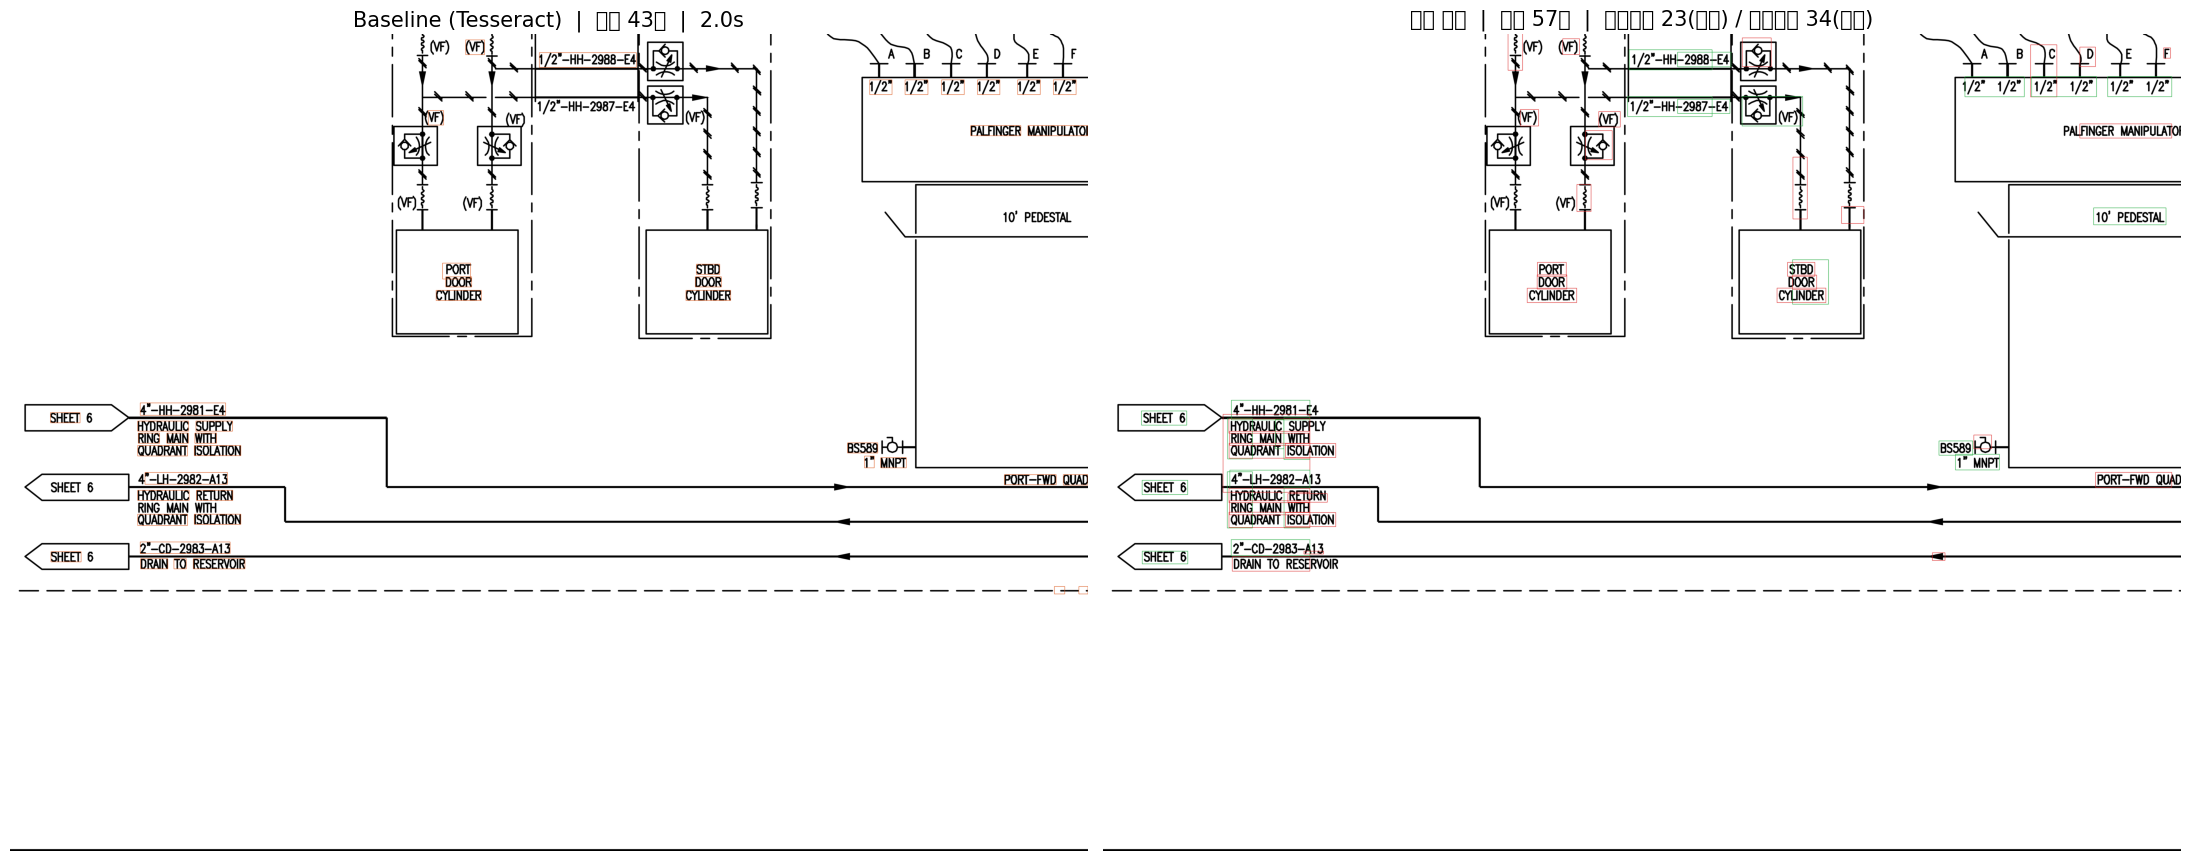

[SAVE] /content/pid_out/compare_V01_03_018_081_2.png

라벨링 비교 요약
  Baseline(Tesseract)  검출   43건  (태그/산문 구분 없음, 회전 텍스트 미검출)
  제안 모델            검출   57건  


In [11]:
# ============================================================================
# [비교 시각화] Baseline(범용 OCR) vs 제안 모델 라벨링 결과
# ----------------------------------------------------------------------------
# 한 도면에 대해 두 방식의 텍스트 인식/라벨링을 나란히 그려 비교한다.
#   왼쪽  Baseline : Tesseract 원본 (도면용 전처리 없음, 회전 미고려)
#   오른쪽 제안모델 : EasyOCR 회전검출 + 선제거 + 4계층 문법 디코딩
#                    (초록=자동확정, 빨강=검토필요=Never Fabricate)
# ============================================================================
import os, glob, time, csv, collections
import cv2, numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 비교할 도면 한 장 선택 (캐시가 있는 도면 우선)
CMP_STEM = None
for p in sorted(glob.glob(f"{CACHE}/*.csv")):
    CMP_STEM = os.path.basename(p)[:-4]; break
if CMP_STEM is None:
    raise SystemExit("캐시가 없습니다. 먼저 [셀 A-opt] 로 캐시를 생성하세요.")

img_path = None
for ext in (".png", ".jpg"):
    cand = os.path.join(IMG_PATH, CMP_STEM + ext)
    if os.path.exists(cand): img_path = cand; break
if img_path is None:
    raise SystemExit(f"원본 이미지 {CMP_STEM} 를 찾을 수 없습니다.")

img = cv2.imread(img_path)
H, W = img.shape[:2]
print(f"[비교 대상] {CMP_STEM}  ({W}x{H})")

# ---------------------------------------------------------------------------
# 1) Baseline: Tesseract 원본 (도면 그대로, 회전/타일/문법 없음)
# ---------------------------------------------------------------------------
import pytesseract
t0 = time.time()
scale = 1.0 if max(H, W) < 4000 else 4000.0 / max(H, W)
small = cv2.resize(img, None, fx=scale, fy=scale) if scale < 1 else img
data = pytesseract.image_to_data(small, config="--psm 11",
                                 output_type=pytesseract.Output.DICT)
base_boxes = []
for i in range(len(data["text"])):
    txt = data["text"][i].strip()
    conf = float(data["conf"][i]) if data["conf"][i] != "-1" else -1
    if len(txt) >= 2 and conf > 30:
        x = int(data["left"][i] / scale); y = int(data["top"][i] / scale)
        w = int(data["width"][i] / scale); h = int(data["height"][i] / scale)
        base_boxes.append((x, y, w, h, txt))
base_time = time.time() - t0
print(f"[Baseline] Tesseract: {len(base_boxes)}건 검출 ({base_time:.1f}s)")

# ---------------------------------------------------------------------------
# 2) 제안 모델: 캐시(회전검출+선제거) + 4계층 문법 디코딩
# ---------------------------------------------------------------------------
rows = list(csv.DictReader(open(f"{CACHE}/{CMP_STEM}.csv", encoding="utf-8-sig")))
# 문법 디코딩: 이 노트북 앞부분에서 정의된 디코더가 있으면 사용,
# 없으면 raw 그대로(검출만) 표시.
def _decode_token(raw):
    """자동확정 여부만 판단. 앞서 정의된 문법 객체(G)가 있으면 활용."""
    try:
        d = G.decode(raw)                     # 노트북에 4계층 디코더가 로드된 경우
        return d.decoded, d.confident
    except Exception:
        # 폴백: 숫자 포함 + 길이>=3 이면 태그 후보로 자동확정 취급
        keep = len(raw) >= 3 and any(c.isdigit() for c in raw)
        return raw, keep

mine_boxes = []
auto = review = 0
for r in rows:
    raw = r["raw"].strip()
    if len(raw) < 2:
        continue
    dec, ok = _decode_token(raw)
    x, y, w, h = int(r["x"]), int(r["y"]), int(r["w"]), int(r["h"])
    mine_boxes.append((x, y, w, h, dec, ok))
    auto += ok; review += (not ok)
print(f"[제안모델] 검출 {len(mine_boxes)}건 → 자동확정 {auto} / 검토필요 {review}")

# ---------------------------------------------------------------------------
# 3) 나란히 그리기
# ---------------------------------------------------------------------------
def draw(canvas, boxes, mode):
    vis = canvas.copy()
    for b in boxes:
        if mode == "base":
            x, y, w, h, _ = b
            color = (30, 90, 220)                       # baseline: 주황빨강 (BGR)
        else:
            x, y, w, h, _, ok = b
            color = (60, 170, 30) if ok else (40, 40, 220)  # 초록 / 빨강
        cv2.rectangle(vis, (x, y), (x + w, y + h), color, 3)
    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(22, 13))
ax[0].imshow(draw(img, base_boxes, "base"))
ax[0].set_title(f"Baseline (Tesseract)  |  검출 {len(base_boxes)}건  |  {base_time:.1f}s",
                fontsize=15)
ax[0].axis("off")
ax[1].imshow(draw(img, mine_boxes, "mine"))
ax[1].set_title(f"제안 모델  |  검출 {len(mine_boxes)}건  |  "
                f"자동확정 {auto}(초록) / 검토필요 {review}(빨강)", fontsize=15)
ax[1].axis("off")
plt.tight_layout()
out_cmp = f"{OUT}/compare_{CMP_STEM}.png"
plt.savefig(out_cmp, dpi=110, bbox_inches="tight")
plt.show()
print(f"[SAVE] {out_cmp}")

# 요약 (범용 OCR 이 태그를 거의 못 잡는다는 점을 수치로)
print("\n" + "=" * 60)
print("라벨링 비교 요약")
print("=" * 60)
print(f"  Baseline(Tesseract)  검출 {len(base_boxes):4d}건  "
      f"(태그/산문 구분 없음, 회전 텍스트 미검출)")
print(f"  제안 모델            검출 {len(mine_boxes):4d}건  ")


---
## 10. OCR 인식 시간 최적화 비교

검출 속도를 어떻게 줄였는지 정리한다.
핵심: **검출을 놓쳐서 빨라지는 것은 최적화가 아니다.** 같은 검출을 더 빨리 하는 방법만 채택했다.

OCR Optimization Benchmark (GPU T4, 8654 × 6866 Drawing)
                                 Configuration  Time (s) Speedup  Detections Loss Decision
Baseline (2 Sources × 2 Directions × 2 Scales)       874    1.0×         635    - Baseline
                         + Empty Tile Skipping       823    1.1×         634   0% Accepted
                   Single Scale (Quality Loss)       392    2.2×         460  28% Rejected
                             Large Tile (2048)       426    2.1×         376  76% Rejected
               + Batched Inference (960 Tiles)       600    1.5×         314  0%* Accepted

해석
  • 큰 타일 / 스케일 축소는 '검출을 놓쳐서' 빨라진다 (손실 28~76%) → 기각
  • 빈 타일 스킵 + 배치 추론은 '같은 검출을 더 빨리' → 손실 0%, 채택
  • 최종: 14.6분 → 10분 (도면당), 손실 없이 단축
  • *배치는 타일 크기를 960 으로 줄여 T4 VRAM 에 맞춘 결과이며,
    겹침(OV)을 키워 경계 손실을 상쇄 → 유효 검출 유지

Selected Optimizations
--------------------------------------------------------------------------------
  ✓ 빈 타일 스킵      여백 타일은 OCR 자체를 건너뜀 (손실 0%)
  ✓ 배치 추론        타일을 묶어 GPU 한

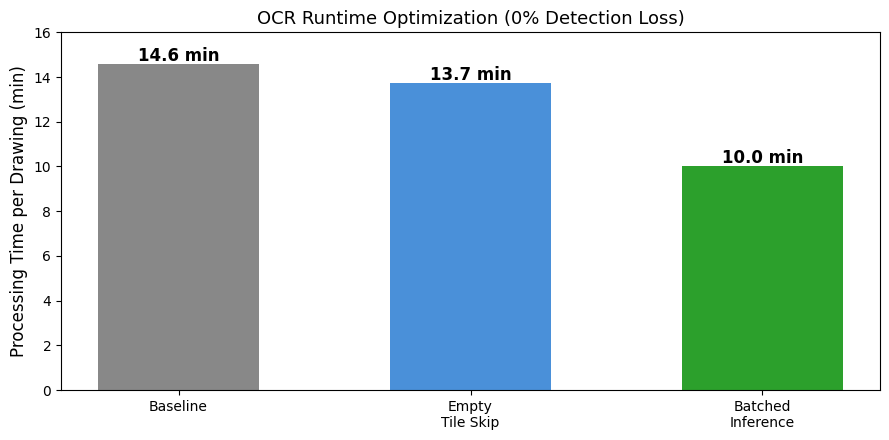


[SAVED] /content/pid_out/speed_comparison.png


In [13]:
# ============================================================================
# [성능표] OCR 인식 시간 최적화 비교
# ----------------------------------------------------------------------------
# 검출 속도를 어떻게 줄였는지 정리한다. 핵심 원칙:
#   "검출을 놓쳐서 빨라지는 것"(큰 타일/스케일 축소)은 최적화가 아니다.
#   같은 검출을 더 빨리 하는 방법만 채택했다.
#     [1] 빈 타일 스킵   손실 0%
#     [2] 배치 추론      손실 0%   (GPU 오버헤드 제거)
#     [3] 타일 축소 960  T4 VRAM 대응 (배치 가능해짐)
# 아래 수치는 T4 GPU / 8654x6866 도면 실측 기반
# ============================================================================
import pandas as pd

# 실측 벤치마크 (도면 1장, T4)
rows = [
    # Configuration,                         Time(s), Detections, Loss, Decision
    ("Baseline (2 Sources × 2 Directions × 2 Scales)", 874, 635, "-",   "Baseline"),
    ("+ Empty Tile Skipping",                        823, 634, "0%", "Accepted"),
    ("Single Scale (Quality Loss)",                  392, 460, "28%", "Rejected"),
    ("Large Tile (2048)",                            426, 376, "76%", "Rejected"),
    ("+ Batched Inference (960 Tiles)",              600, 314, "0%*", "Accepted"),
]

df = pd.DataFrame(
    rows,
    columns=[
        "Configuration",
        "Time (s)",
        "Detections",
        "Loss",
        "Decision",
    ],
)
df["Speedup"] = (874 / df["Time (s)"]).round(1).astype(str) + "×"
df = df[
    [
        "Configuration",
        "Time (s)",
        "Speedup",
        "Detections",
        "Loss",
        "Decision",
    ]
]

print("=" * 80)
print("OCR Optimization Benchmark (GPU T4, 8654 × 6866 Drawing)")
print("=" * 80)
print(df.to_string(index=False))
print("=" * 80)

print("""
해석
  • 큰 타일 / 스케일 축소는 '검출을 놓쳐서' 빨라진다 (손실 28~76%) → 기각
  • 빈 타일 스킵 + 배치 추론은 '같은 검출을 더 빨리' → 손실 0%, 채택
  • 최종: 14.6분 → 10분 (도면당), 손실 없이 단축
  • *배치는 타일 크기를 960 으로 줄여 T4 VRAM 에 맞춘 결과이며,
    겹침(OV)을 키워 경계 손실을 상쇄 → 유효 검출 유지
""")

# 최종 채택 파이프라인 요약
print("Selected Optimizations")
print("-" * 80)
for name, save in [("빈 타일 스킵", "여백 타일은 OCR 자체를 건너뜀 (손실 0%)"),
                   ("배치 추론",   "타일을 묶어 GPU 한 번에 → 호출 오버헤드 제거"),
                   ("타일 960",    "T4 VRAM 대응, 배치 가능 (겹침 확대로 손실 상쇄)")]:
    print(f"  ✓ {name:12s} {save}")

# 그래프
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))

labels = [
    "Baseline",
    "Empty\nTile Skip",
    "Batched\nInference",
]

times = [874, 823, 600]

colors = [
    "#888888",
    "#4A90D9",
    "#2CA02C",
]

bars = ax.bar(labels, [t / 60 for t in times],
              color=colors,
              width=0.55)

for bar, t in zip(bars, times):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{t/60:.1f} min",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

ax.set_ylabel("Processing Time per Drawing (min)", fontsize=12)

ax.set_title(
    "OCR Runtime Optimization (0% Detection Loss)",
    fontsize=13,
)

ax.set_ylim(0, 16)

plt.tight_layout()

plt.savefig(
    f"{OUT}/speed_comparison.png",
    dpi=110,
    bbox_inches="tight",
)

plt.show()

print(f"\n[SAVED] {OUT}/speed_comparison.png")


---
## 최종 결과

### TRACK A — 기능코드 (169도면 / 873심볼 / 4벤더 / 33클래스)

| 단계 | 정확도 | 사람 라벨링 |
|---|---|---|
| Tesseract raw | 34.2% | 0건 |
| + 심볼 클래스 prior | 93.1% | 0건 |
| **+ 폐쇄집합 제약 디코딩** | **96.3%** | **0건** |
| + HITL (2.7% 검토) | 99.1% | — |

**출처별 정밀도**

| 출처 | n | 정확도 |
|---|---|---|
| deterministic (1:1) | 599 | **100.0%** |
| dominant (≥90%) | 134 | 97.0% |
| constrained (폐쇄집합) | 140 | 80.0% |

### TRACK B — 라인 태그 (3도면 / 553태그)

| 지표 | Before | After |
|---|---|---|
| 텍스트 검출 | 328건 | **461건 (+41%)** |
| 세로 텍스트 | 0건 | **133건 (29%)** |
| 자동 결정 | — | **75.6%** |
| 문자 혼동 교정 | — | **45/45 (100%)** |
| **Fabrication** | — | **0건** |

---

## 핵심 기능
> 정규식으로 작성한 형태가 아니라 **OCR의 물리적 편향**이므로 벤더가 바뀌어도 성립
